# Multi-Class Classification with Perceptron

Lab Assignment from [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners).

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
import random

You can use the following perceptron training code from the lecture:

In [4]:
def train(positive_examples, negative_examples, num_iterations = 100,n=1):
    num_dims = positive_examples.shape[1]
    weights = np.zeros((num_dims,1)) # initialize weights
    
    pos_count = positive_examples.shape[0]
    neg_count = negative_examples.shape[0]
    
    report_frequency = 10
    
    for i in range(num_iterations):
        pos = random.choice(positive_examples)
        neg = random.choice(negative_examples)

        z = np.dot(pos, weights)   
        if z < 0:
            weights = weights + n*pos.reshape(weights.shape)

        z  = np.dot(neg, weights)
        if z >= 0:
            weights = weights - n*neg.reshape(weights.shape)
            
        if i % report_frequency == 0:             
            pos_out = np.dot(positive_examples, weights)
            neg_out = np.dot(negative_examples, weights)        
            pos_correct = (pos_out >= 0).sum() / float(pos_count)
            neg_correct = (neg_out < 0).sum() / float(neg_count)
            print("Iteration={}, pos correct={}, neg correct={}".format(i,pos_correct,neg_correct))

    return weights

In [5]:
def accuracy(weights, test_x, test_labels):
    res = np.dot(test_x, weights)
    return (res.reshape(test_labels.shape) * test_labels >= 0).sum() / float(len(test_labels))


### Reading the Dataset

This code download the dataset from the repository on the internet. You can also manually copy the dataset from `/data` directory of AI Curriculum repo.

In [6]:
#!rm *.pkl
#https://github.com/mnielsen/neural-networks-and-deep-learning/blob/master/data/mnist.pkl.gz!gzip -d mnist.pkl.gz

In [7]:
with open('mnist.pkl', 'rb') as f:
    MNIST = pickle.load(f, encoding='latin1')

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01171875 0.0703125
 0.0703125  0.0703125  0.4921875  0.53125    0.68359375 0.1015625
 0.6484375  0.99609375 0.96484375 0.49609375 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.1171875  0.140625
 0.3671875  0.6015625 ]
5


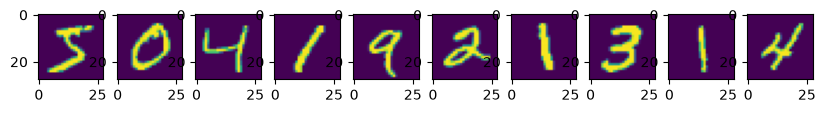

In [8]:
print(MNIST[0][0][0][130:180])
print(MNIST[0][1][0])
features = MNIST[0][0].astype(np.float32) / 256.0
labels = MNIST[0][1]
fig = plt.figure(figsize=(10,5))
for i in range(10):
    ax = fig.add_subplot(1,10,i+1)
    plt.imshow(features[i].reshape(28,28))
plt.show()

Code to create *one-vs-other* dataset for two-digit classification. You need to modify this code to create *one-vs-all* dateset.

In [9]:
def set_mnist_one_vs_all(digit):
    positive_indices = np.where(train_y == digit)[0]
    negative_indices = np.where(train_y != digit)[0]

    positive_images = train_x[positive_indices]
    negative_images = train_x[negative_indices]

    return positive_images, negative_images

Now you need to:
1. Create 10 *one-vs-all* datasets for all digits
1. Train 10 perceptrons
1. Define `classify` function to perform digit classification
1. Measure the accuracy of classification and print *confusion matrix*
1. [Optional] Create improved `classify` function that performs the classification using one matrix multiplication.

In [10]:
train_x = MNIST[0][0]
train_y = MNIST[0][1]

test_x = MNIST[2][0]
test_y = MNIST[2][1]

In [11]:
print(train_x.shape)
print(train_y.shape)

print(test_x.shape)
print(test_y.shape)

(50000, 784)
(50000,)
(10000, 784)
(10000,)


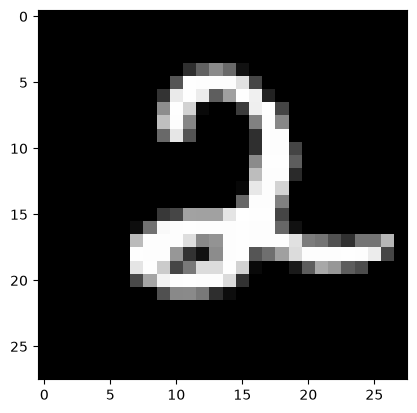

Правильный ответ: 2


In [12]:
import random
i = random.randrange(len(train_x))
plt.imshow(train_x[i].reshape(28, 28), cmap='gray')
plt.show()

print("Правильный ответ:", train_y[i])

In [13]:
for i in range(10):
    positive_images, negative_images = set_mnist_one_vs_all(i)
    globals()[f"positive_images_{i}"] = positive_images
    globals()[f"negative_images_{i}"] = negative_images




In [14]:
for i in range(10):
    if i == 0:
        pos = positive_images
        neg = negative_images
    else:
        pos = globals()[f"positive_images_{i}"]
        neg = globals()[f"negative_images_{i}"]

    globals()[f"w{i}"] = train(pos, neg, num_iterations=1500,n=1)

Iteration=0, pos correct=0.0, neg correct=1.0
Iteration=10, pos correct=0.8035284683239775, neg correct=0.8318004087798809
Iteration=20, pos correct=0.9512830793905372, neg correct=0.6615347018572825
Iteration=30, pos correct=0.9585004009623096, neg correct=0.6230560739358393
Iteration=40, pos correct=0.8650761828388132, neg correct=0.8206033946503155
Iteration=50, pos correct=0.535084202085004, neg correct=0.9488358659912912
Iteration=60, pos correct=0.9691259021651965, neg correct=0.6585577179418821
Iteration=70, pos correct=0.4115878107457899, neg correct=0.975028881187239
Iteration=80, pos correct=0.6515637530072174, neg correct=0.9400604283302231
Iteration=90, pos correct=0.9414595028067362, neg correct=0.7316937705500756
Iteration=100, pos correct=0.9777465918203689, neg correct=0.6289656091708877
Iteration=110, pos correct=0.9188051323175621, neg correct=0.7974762285612725
Iteration=120, pos correct=0.9444667201283079, neg correct=0.8034079800941971
Iteration=130, pos correct=0.

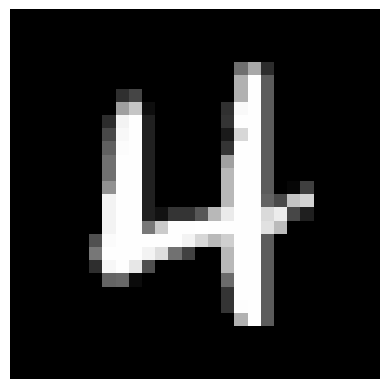

Настоящая цифра: 4
Score: [-186.29928589]
Перцептрон говорит: Нет


In [20]:
import random

i = random.randrange(len(test_x))

image = test_x[i]

plt.imshow(image.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

score = np.dot(image, w1)

print("Настоящая цифра:", test_y[i])
print("Score:", score)

if score >= 0:
    print("Перцептрон говорит: Да")
else:
    print("Перцептрон говорит: Нет")

In [21]:
for i in range(10):
    test_labels_i = np.where(test_y == i, 1, -1)
    w = globals()[f"w{i}"]
    
    acc = accuracy(w, test_x, test_labels_i)
    
    print("Digit", i, "accuracy:", acc)

Digit 0 accuracy: 0.6641
Digit 1 accuracy: 0.9832
Digit 2 accuracy: 0.9623
Digit 3 accuracy: 0.962
Digit 4 accuracy: 0.9399
Digit 5 accuracy: 0.9211
Digit 6 accuracy: 0.9485
Digit 7 accuracy: 0.9592
Digit 8 accuracy: 0.7018
Digit 9 accuracy: 0.8838


In [22]:
weights = [w0, w1, w2, w3, w4, w5, w6, w7, w8, w9]
def classify(images, weights):
    predictions = []

    for image in images:
        scores = []

        for weight in weights:
            score = np.dot(image, weight)
            scores.append(score)

        prediction = np.argmax(scores)
        predictions.append(prediction)

    return np.array(predictions)
   

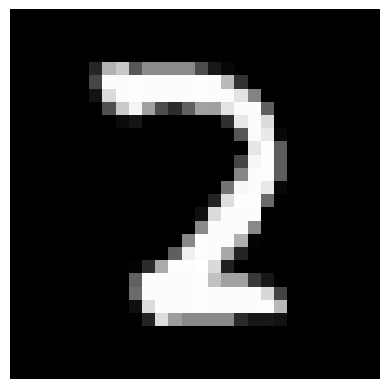

Настоящая цифра: 2
Перцептрон говорит: 2


In [25]:
import random
import matplotlib.pyplot as plt

i = random.randrange(len(test_x))

image = test_x[i]

plt.imshow(image.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

prediction = classify([image], weights)[0]

print("Настоящая цифра:", test_y[i])
print("Перцептрон говорит:", prediction)

In [26]:
predictions = classify(test_x, weights)

accuracy = (predictions == test_y).mean()

print("Accuracy:", accuracy)

Accuracy: 0.6945


In [35]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from ipycanvas import Canvas


# ============================================================
# 1. CANVAS
# ============================================================

canvas = Canvas(width=280, height=280)

canvas.sync_image_data = True

# Белый фон
canvas.fill_style = '#000000'
canvas.fill_rect(0, 0, 280, 280)

# Чёрная кисть
canvas.stroke_style = '#ffffff'
canvas.line_width = 20
canvas.line_cap = 'round'

display(canvas)


# ============================================================
# 2. РИСОВАНИЕ
# ============================================================

drawing = False


def start_drawing(x, y):
    global drawing

    drawing = True

    canvas.begin_path()
    canvas.move_to(x, y)


def draw(x, y):
    if drawing:
        canvas.line_to(x, y)
        canvas.stroke()


def stop_drawing(x, y):
    global drawing

    drawing = False


canvas.on_mouse_down(start_drawing)
canvas.on_mouse_move(draw)
canvas.on_mouse_up(stop_drawing)


# ============================================================
# 3. ВЕСА
# ============================================================

weights = [
    w0, w1, w2, w3, w4,
    w5, w6, w7, w8, w9
]


# ============================================================
# 4. КНОПКА
# ============================================================

button = widgets.Button(description="Распознать")
output = widgets.Output()

display(button)
display(output)


# ============================================================
# 5. РАСПОЗНАВАНИЕ ЧЕРЕЗ classify()
# ============================================================

def recognize(b):

    with output:
        output.clear_output()

        image_data = canvas.get_image_data()
        image = np.array(image_data)

        # RGB -> один канал
        image = image[:, :, 0]

        # 280x280 -> 28x28
        image = image.reshape(28, 10, 28, 10).mean(axis=(1, 3))



        # Нормализация
        image = image / 256.0

        # ПОКАЗЫВАЕМ, ЧТО ПОЛУЧИЛА МОДЕЛЬ
        plt.figure(figsize=(4, 4))
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        plt.show()

        # 28x28 -> 784
        image = image.reshape(784)

        prediction = classify([image], weights)[0]

        print("Распознано:", prediction)


# ============================================================
# 6. ПРИВЯЗЫВАЕМ КНОПКУ
# ============================================================

button.on_click(recognize)

Canvas(height=280, sync_image_data=True, width=280)

Button(description='Распознать', style=ButtonStyle())

Output()

In [1]:
%whos

Interactive namespace is empty.
